In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix, classification_report
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

plt.rcParams['figure.figsize'] = (5,4)


# Motor de recomendación: Predicción de compras y recomendación de productos

## Entregable
Función `recomendador_by_date(fecha)` que asigna a cada cliente con probabilidad alta de compra, sus **5 productos top de su histórico**

## Objetivos
- **Predecir**, Dada un fecha, calcular la probabilidad de realizar al menos una compra de un cliente.  
- **Recomendar** los productos más adecuados a los clientes con alta probabilidad de compra.
        La recomendación es en base al historico del cliente

---

## Integración de datos
1. **Ventas históricas** (≈ 15 meses) con detalle de cliente, fecha, producto y cantidad.  
2. **Catálogo de productos** con descripciones y claves únicas.  

Las claves se estandarizan a texto y se valida la consistencia antes del análisis.

---

## Datos base
 Se trabaja con los clientes que compran con domicio. Para estos clientes se toman sus
 compras tanto por domicio, como presencial y que cumplen que al menos en los 15 meses hallan comprado
 en más de 10 días diferentes. Adicional, los clientes deben de tener al menos 5 productos distintos.

## Feature Engineer

A partir del calendario completo **cliente‑fecha** se crean dos grupos de variables explicativas:

| Grupo | Variable | Descripción |
|-------|----------|-------------|
| **Temporales** | `dow` | Día de la semana |
| | `dom` | Día del mes |
| | `month` | Mes |
| | `is_weekend` | Indicador de fin de semana |
| | `is_quincena` | Indicador de quincena (28, 29, 30, 31, 1, 2, 13, 14, 15, 16 de cada mes) |
| | `days_since_last` | Días transcurridos desde la última compra |
| **Ventanas móviles (*lagged counts*)** | `cnt_1d` | Compras del cliente en el **día previo** |
| | `cnt_3d` | Compras acumuladas en los **3 días previos** |
| | `cnt_7d` | Compras acumuladas en la **última semana** |
| | `cnt_15d` | Compras acumuladas en los **últimos 15 días** |
| | `cnt_30d` | Compras acumuladas en el **último mes** |

Los conteos por ventana se calculan con un *rolling window* desplazado una fila para evitar fuga de información hacia el futuro:

---

## Construcción del dataset
Se crea un calendario para cada cliente, los días un cliente no tiene información, se llenan con cero, construyendo la siguiente etiqueta binaria  **`purchased`**:
  - `1` si el cliente compró ese día.  
  - `0` en caso contrario.  

---

## Partición de datos
- **entrenamiento** Todos los registros para clientes con compras desde la fecha más reciente hacia atras 30 días
- **prueba**   30 días.
- **calibración y revisión** Registros de Abril del 2025 
*(estratificado por la variable objetivo).*

---

## Modelo y calibración
- **Algoritmo:** Regresión Logística.  
- **Recalibración:** `CalibratedClassifierCV` para mejorar la confiabilidad de las probabilidades.

---

## Evaluación
- **Métrica principal:** Curva **Precisión‑Recall**.  
  - Con umbral **0,50** se logra **Precisión 0.59%** y **Bierf Score 0.072%** Después de calibrado.  
- Matrices de confusión y curvas confirman la solidez del modelo.

---

## Motor de recomendación
La función `recomendador_by_date(fecha)`:
1. Aplica el modelo a la fecha futura indicada.  
2. Filtra clientes con **probabilidad ≥ 0,50**.  
3. Asigna a cada cliente sus **5 productos más comprados históricamente** como recomendación priorizada.

---


---

## Próximos pasos
- Incluir todos los clientes presenciales, lugar de compra, valor de compra.
- Definir muy bien los clientes objetivos: Cuantas interaciones de ventas se deben de tener por cliente?
- Mejores técnicas de calibración.
- Evaluar modelos de **árboles de gradiente** y comparar desempeño.  
- **Automatizar** el retrain mensual y la generación diaria de recomendaciones.

---

### Carga de datos

In [2]:
productos = pd.read_csv(f"../data/raw/productos.csv", dtype={"codigo_unico": str}).rename(columns={"codigo_unico": "product"})
productos = productos.loc[:, ["product", "description", "brand", "category"]]
productos = productos.drop_duplicates("product")
productos['product'] = productos['product'].str.strip()

terceros = pd.read_csv(f"../data/raw/terceros_completo.csv", converters={"document": str})
terceros = terceros.drop_duplicates("document")
terceros = terceros.loc[:, ["document", "email", "telephone", "name"]]
terceros['document'] = terceros['document'].str.strip()


In [3]:
cols = [
    'date_sale',
    'id_point_sale',
    'identification_doct',
    'product',
    'invoice_value_with_discount_and_without_iva',
    'domicilio_status',
    'amount'

]

ventas = pd.read_csv(f"../data/raw/ventas_completo.csv", usecols=cols,
    dtype={
        'identification_doct': str,
        'product': str
    })
ventas['identification_doct'] = ventas['identification_doct'].str.strip()
ventas['product'] = ventas['product'].str.strip()

# 4. Convertir date_sale a datetime
ventas['date_sale'] = pd.to_datetime(
    ventas['date_sale'],
    errors='coerce',
    dayfirst=True       # ajusta según tu formato (True si el CSV usa DD/MM/YYYY)
)
ventas_new = pd.read_csv(f"../data/raw/ventas_backtesting_exploted.csv", usecols=cols,
    dtype={
        'identification_doct': str,
        'product': str
    })

ventas_new['identification_doct'] = ventas_new['identification_doct'].str.strip()
ventas['product'] = ventas['product'].str.strip()

# 4. Convertir date_sale a datetime
ventas_new['date_sale'] = pd.to_datetime(
    ventas_new['date_sale'],
    errors='coerce',
    dayfirst=True       # ajusta según tu formato (True si el CSV usa DD/MM/YYYY)
)
ventas = pd.concat([ventas, ventas_new])
#ventas = pd.read_parquet("../data/raw/ventas_domicilio_filtered_.parquet")

In [4]:
ventas['id_client'] = ventas['identification_doct'].astype(str).str.strip()
mask_digits = ventas["id_client"].str.isdigit()
mask_zero = ~ventas["id_client"].str.startswith("0", na=False)
df = ventas[mask_digits & mask_zero].copy()
print(f"Filas tras filtrar id_client no numéricos/cero inicial: {len(df)}")

df['product'] = df['product'].astype(str).str.strip()
df['date_sale'] = pd.to_datetime(df['date_sale'], errors='coerce', dayfirst=True)
df = df.dropna(subset=['date_sale'])
df['date_sale'] = df['date_sale'].dt.normalize()

Filas tras filtrar id_client no numéricos/cero inicial: 51962758


In [5]:
df["domicilio_status"].value_counts()

False    51066504
True       896254
Name: domicilio_status, dtype: int64

In [6]:
# --- Filtrado por Domicilio ---
print("Filtrando por clientes con historial de domicilio...")
client_dom = df[df["domicilio_status"].isin(["True", "true", True])]["id_client"].unique()
print(f"Número de clientes únicos con al menos 1 compra a domicilio: {len(client_dom)}")
df_filtered = df[df["id_client"].isin(client_dom)].copy()
print(f"Filas tras filtrar por clientes con domicilio: {len(df_filtered)}")

Filtrando por clientes con historial de domicilio...
Número de clientes únicos con al menos 1 compra a domicilio: 7615
Filas tras filtrar por clientes con domicilio: 2835225


In [7]:
df_filtered.head()

,date_sale,id_point_sale,identification_doct,invoice_value_with_discount_and_without_iva,domicilio_status,product,amount,id_client
187,2024-01-01,MIX,222222222222222,16439.0,False,250171,1.0,222222222222222
188,2024-01-01,MIX,222222222222222,16439.0,False,116532,1.0,222222222222222
189,2024-01-01,MIX,222222222222222,16439.0,False,71477,2.0,222222222222222
190,2024-01-01,MIX,222222222222222,16439.0,False,250171,1.0,222222222222222
191,2024-01-01,MIX,222222222222222,16439.0,False,116532,1.0,222222222222222


In [8]:

print(f"Calculando patrones de compra (requiere min días de compra)...")
daily_purchases = df_filtered.drop_duplicates(subset=['id_client', 'date_sale'])[['id_client', 'date_sale']]
daily_purchases = daily_purchases.sort_values(['id_client', 'date_sale'])
daily_purchases['days_between_purchases'] = daily_purchases.groupby('id_client')['date_sale'].diff().dt.days
patterns = daily_purchases.groupby('id_client').agg(
    last_purchase_date=('date_sale', 'max'),
    first_purchase_date=('date_sale', 'min'),
    purchase_days_count=('date_sale', 'nunique'),
    avg_days_between=('days_between_purchases', 'mean'),
    median_days_between=('days_between_purchases', 'median'),
    std_days_between=('days_between_purchases', 'std')
).reset_index()



Calculando patrones de compra (requiere min días de compra)...


In [9]:
patterns

,id_client,last_purchase_date,first_purchase_date,purchase_days_count,avg_days_between,median_days_between,std_days_between
0,1000000001,2025-03-22,2025-03-22,1,NaN,NaN,NaN
1,1000086962,2025-02-05,2025-02-05,1,NaN,NaN,NaN
2,1000099532,2024-03-12,2024-03-12,1,NaN,NaN,NaN
3,1000100032,2025-04-05,2025-04-05,1,NaN,NaN,NaN
4,1000101303,2025-03-28,2025-03-07,2,21.000000,21.0,NaN
...,...,...,...,...,...,...,...
7610,98772770,2025-03-19,2024-01-12,22,20.571429,14.0,21.590673
7611,98773050,2025-04-19,2024-01-03,40,12.102564,14.0,6.707399
7612,98793,2025-04-01,2024-02-06,21,21.000000,19.5,9.239503
7613,9955900,2025-04-08,2024-01-04,75,6.216216,4.0,6.881124


In [11]:
patterns["avg_days_between"].value_counts()

1.000000     31
14.000000    23
21.000000    22
9.000000     22
12.000000    22
             ..
15.206897     1
22.833333     1
6.337838      1
20.166667     1
14.300000     1
Name: avg_days_between, Length: 3606, dtype: int64

In [ ]:
MIN_PURCHASE_COUNT = 5
MIN_MEDIAN = 30
MIN_STD = 5

patterns_filtered = patterns[patterns['purchase_days_count'] >= MIN_PURCHASE_COUNT].copy()
print(f"Clientes con >= {MIN_PURCHASE_COUNT} días de compra: {len(patterns_filtered)}")
patterns_filtered  = patterns_filtered[patterns_filtered["median_days_between"]<MIN_MEDIAN]
print(f"Clientes con compras recurrentes cada mes  {MIN_MEDIAN} días de compra: {len(patterns_filtered)}")
patterns_filtered  = patterns_filtered[patterns_filtered["std_days_between"]<MIN_STD]
print(f"Clientes con compras recurrentes cada mes  {MIN_STD} días de compra: {len(patterns_filtered)}")

In [13]:
patterns_filtered.head()

,id_client,last_purchase_date,first_purchase_date,purchase_days_count,avg_days_between,median_days_between,std_days_between
18,1000402618,2025-04-14,2024-01-02,314,1.495208,1.0,0.940954
33,1000439204,2024-09-16,2024-03-14,98,1.917526,1.0,1.605136
34,1000442176,2025-02-15,2024-08-26,49,3.604167,3.0,3.167250
46,1000566458,2025-04-17,2024-01-02,122,3.892562,2.0,3.964008
65,1001017147,2025-04-19,2024-01-02,167,2.849398,2.0,2.438622


In [14]:
df_filtered_cut = df_filtered[df_filtered["id_client"].isin(patterns_filtered["id_client"])]

In [15]:
df_filtered_cut.shape

(967276, 8)

In [16]:
df_filtered_cut.head()

,date_sale,id_point_sale,identification_doct,invoice_value_with_discount_and_without_iva,domicilio_status,product,amount,id_client
2550,2024-01-01,CAR,1129523771,16117.0,False,325487,1.000,1129523771
2551,2024-01-01,CAR,1129523771,16117.0,False,252490,1.000,1129523771
2552,2024-01-01,CAR,1129523771,16117.0,False,122235,2.706,1129523771
4347,2024-01-01,FRO,43684411,197793.0,False,248879,1.000,43684411
4348,2024-01-01,FRO,43684411,197793.0,False,81500,1.495,43684411


In [21]:
cols = ["date_sale",
        "id_client",
        "id_point_sale",
        "product",
        "invoice_value_with_discount_and_without_iva",
        "domicilio_status",
        "amount"
        ]
df_filtered_cut_recom = df_filtered_cut[cols].copy()

In [22]:
df_filtered_cut_recom.to_csv("data_recomendacion.csv", index=False)

In [186]:
max_hist_date = df_filtered_cut['date_sale'].max()
print(f"Fecha máxima encontrada en los datos filtrados: {max_hist_date.strftime('%Y-%m-%d')}")

# Renombrar y seleccionar columnas
df_filtered = df_filtered_cut.rename(columns={
    'invoice_value_with_discount_and_without_iva': 'amount_paid',
    'amount': 'quantity'
})
df_filtered = df_filtered[['date_sale', 'id_client', 'product', 'quantity', 'amount_paid']].copy()

# Agrupar para evitar duplicados por producto en el mismo día/cliente
df_filtered = df_filtered.groupby(['date_sale', 'id_client', 'product']).agg(
    {"quantity": "sum", "amount_paid": "sum"}
).reset_index()
df_filtered.sort_values(['id_client', 'date_sale'], inplace=True)

Fecha máxima encontrada en los datos filtrados: 2025-04-21


In [187]:
df_filtered.head()

,date_sale,id_client,product,quantity,amount_paid
297,2024-01-02,1000402618,87338,2.000,2112.0
1646,2024-01-03,1000402618,115157,1.000,7404.0
4349,2024-01-04,1000402618,87338,2.000,2111.0
5976,2024-01-05,1000402618,116075,1.000,2818.0
5977,2024-01-05,1000402618,121689,0.405,40421.0


In [188]:
ventas = df_filtered.copy()

### Entendimiento de datos

## Datos: clientes que comprar por domicilio y también  en lugar presencial

In [189]:
print(f"Clientes distintos que compran por domicilio y presencial: {ventas["id_client"].nunique()}")

Clientes distintos que compran por domicilio y presencial: 700


#### Clientes que  al menos han comprado en 10 dias distintos y en todas sus compras al menos 5 productos

In [190]:

resumen = (ventas
           .groupby('id_client')
           .agg(num_fechas=('date_sale', 'nunique'),      # días de compra distintos
                num_productos=('product', 'nunique'))     # productos distintos
           .reset_index())



In [191]:
resumen["num_fechas"].describe()

count    700.000000
mean     120.208571
std       88.546631
min        5.000000
25%       66.000000
50%       94.500000
75%      154.250000
max      462.000000
Name: num_fechas, dtype: float64

In [192]:
resumen["num_productos"].describe()

count     700.000000
mean      359.120000
std       226.293573
min         5.000000
25%       191.750000
50%       339.500000
75%       485.500000
max      1367.000000
Name: num_productos, dtype: float64

In [193]:
# --- 3. Filtrar clientes que cumplen ambas condiciones ---
clientes_objetivo = resumen[
    (resumen['num_fechas'] > 10) &
    (resumen['num_productos'] > 5) #& (resumen['num_productos'] < 50)
]

# --- 4. (Opcional) obtener solo la lista de IDs ---
lista_ids = clientes_objetivo['id_client'].tolist()

len(lista_ids)

662

In [194]:
clientes_objetivo

,id_client,num_fechas,num_productos
0,1000402618,314,1007
1,1000439204,98,116
2,1000442176,49,122
3,1000566458,122,338
4,1001017147,167,250
...,...,...,...
695,98656874,189,260
696,98661604,36,105
697,98666759,118,417
698,98667957,81,197


In [195]:
df_tot = ventas[ventas["id_client"].isin(clientes_objetivo["id_client"])]

In [196]:
df_tot.shape

(933978, 5)

In [197]:
print('Filas totales:', len(df_tot))
print('Rango de fechas:', df_tot['date_sale'].min(), '→', df_tot['date_sale'].max())
print('Clientes únicos:', df_tot['id_client'].nunique())

Filas totales: 933978
Rango de fechas: 2024-01-01 00:00:00 → 2025-04-21 00:00:00
Clientes únicos: 662


In [198]:
"""
Filas totales: 2512495
Rango de fechas: 2024-01-01 00:00:00 → 2025-04-14 00:00:00
Clientes únicos: 3574

"""

'\nFilas totales: 2512495\nRango de fechas: 2024-01-01 00:00:00 → 2025-04-14 00:00:00\nClientes únicos: 3574\n\n'

In [199]:
cond = df_tot["date_sale"] < '2025-04-01'
df_ventas = df_tot#[cond]
df_test = df_tot[~cond].copy()

In [200]:
df_ventas.shape

(933978, 5)

In [201]:
df_tot

,date_sale,id_client,product,quantity,amount_paid
297,2024-01-02,1000402618,87338,2.000,2112.0
1646,2024-01-03,1000402618,115157,1.000,7404.0
4349,2024-01-04,1000402618,87338,2.000,2111.0
5976,2024-01-05,1000402618,116075,1.000,2818.0
5977,2024-01-05,1000402618,121689,0.405,40421.0
...,...,...,...,...,...
936728,2025-04-19,98668949,332167,1.000,10282.0
936729,2025-04-19,98668949,77623,1.000,10282.0
938310,2025-04-20,98668949,115559,1.000,14551.0
938311,2025-04-20,98668949,330273,1.000,14551.0


In [202]:

df = df_tot.copy()
#'id_point_sale', 


In [203]:
daily = (df.groupby(['id_client','date_sale'], as_index=False)
            .agg(qty_tot=('quantity','sum'),
                 amount_tot=('amount_paid','sum'),
                 skus=('product','nunique'))
            .assign(purchased=1)
            .rename(columns={'id_cl':'client','date_sale':'date'}))
daily.head()

,id_client,date,qty_tot,amount_tot,skus,purchased
0,1000402618,2024-01-02,2.000,2112.0,1,1
1,1000402618,2024-01-03,1.000,7404.0,1,1
2,1000402618,2024-01-04,2.000,2111.0,1,1
3,1000402618,2024-01-05,7.795,326186.0,9,1
4,1000402618,2024-01-06,8.954,829183.0,14,1


In [204]:
daily.to_csv("daily.csv", index=False)
daily.rename(columns={'id_client':'client','date_sale':'date'}, inplace=True)

In [206]:
min_date = daily['date'].min()
# TODO: PONER FEchas de forma dinámica
future_dates = pd.date_range('2025-04-21','2025-04-30',freq='D') #'2025-04-01'

full_idx = pd.MultiIndex.from_product(
    [daily['client'].unique(),
     pd.date_range(min_date, future_dates.max(), freq='D')],
    names=['client','date'])

calendar = (daily.set_index(['client','date'])
            .reindex(full_idx, fill_value=0)
            .reset_index())

# Features de fecha
calendar['dow'] = calendar['date'].dt.dayofweek
calendar['dom'] = calendar['date'].dt.day
calendar['month'] = calendar['date'].dt.month
calendar['is_weekend'] = calendar['dow'].isin([5,6]).astype(int)
calendar['is_quincena'] = (calendar['dom'].isin([28, 29, 30, 31, 1, 2, 13, 14, 15, 16])).astype(int)

# Recencia
# Recencia  (versión sin warning)
calendar.sort_values(['client', 'date'], inplace=True)

calendar['prev_buy'] = (
    calendar
      .groupby('client', group_keys=False)['date']        #  ← aquí el cambio
      .apply(lambda s: s.where(calendar.loc[s.index, 'purchased'].eq(1)).ffill())
)

calendar['days_since_last'] = (
    (calendar['date'] - calendar['prev_buy']).dt.days.fillna(9999).astype(int)
)
calendar.drop(columns='prev_buy', inplace=True)


# Ventanas móviles
for w in [1,3,7,15,30]:
    calendar[f'cnt_{w}d'] = (calendar.groupby('client')['purchased']
                             .transform(lambda x: x.rolling(w,min_periods=1).sum().shift(1).fillna(0)))

calendar.head()

,client,date,qty_tot,amount_tot,skus,purchased,dow,dom,month,is_weekend,is_quincena,days_since_last,cnt_1d,cnt_3d,cnt_7d,cnt_15d,cnt_30d
0,1000402618,2024-01-01,0.000,0.0,0,0,0,1,1,0,1,9999,0.0,0.0,0.0,0.0,0.0
1,1000402618,2024-01-02,2.000,2112.0,1,1,1,2,1,0,1,0,0.0,0.0,0.0,0.0,0.0
2,1000402618,2024-01-03,1.000,7404.0,1,1,2,3,1,0,0,0,1.0,1.0,1.0,1.0,1.0
3,1000402618,2024-01-04,2.000,2111.0,1,1,3,4,1,0,0,0,1.0,2.0,2.0,2.0,2.0
4,1000402618,2024-01-05,7.795,326186.0,9,1,4,5,1,0,0,0,1.0,3.0,3.0,3.0,3.0


In [207]:
calendar['purchased'].value_counts(normalize=True)

0    0.73919
1    0.26081
Name: purchased, dtype: float64

In [208]:
max_hist = daily["date"].max()
train_mask = calendar["date"] <= max_hist - pd.Timedelta(days=30)
valid_mask = (calendar["date"] > max_hist - pd.Timedelta(days=30)) & \
             (calendar["date"] <= max_hist)
features = [
    'dow',
    'dom',
    'month',
    'is_weekend','is_quincena',
            'days_since_last'] + [f'cnt_{w}d' for w in [1,3,7,15,30]
                                  ]

X_train, y_train = calendar.loc[train_mask, features], calendar.loc[train_mask,'purchased']
X_valid, y_valid = calendar.loc[valid_mask, features], calendar.loc[valid_mask,'purchased']
print(X_train.shape, X_valid.shape)

(295914, 11) (19860, 11)


In [209]:
print(y_valid.value_counts(normalize=True)) 

0    0.757402
1    0.242598
Name: purchased, dtype: float64


In [210]:
y_valid.shape

(19860,)

In [211]:
print(y_train.value_counts(normalize=True))

0    0.732716
1    0.267284
Name: purchased, dtype: float64


In [212]:
y_train.shape

(295914,)

In [213]:
pipe = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(
        solver='saga',
        max_iter=100,
        tol=1e-3,
        C=0.1,
        class_weight='balanced',
        n_jobs=-1
    )
)
pipe.fit(X_train, y_train)
print('Iteraciones:', pipe.named_steps['logisticregression'].n_iter_[0])

Iteraciones: 30


In [214]:
y_pred = pipe.predict(X_valid)
y_prob = pipe.predict_proba(X_valid)[:,1]
print('ROC-AUC:', roc_auc_score(y_valid,y_prob).round(3))
print('Brier :', brier_score_loss(y_valid,y_prob).round(3))
print('Confusion\n', confusion_matrix(y_valid,y_pred))
print(classification_report(y_valid,y_pred, digits=3)) #0.05---->bir 0.11, 4410

ROC-AUC: 0.772
Brier : 0.2
Confusion
 [[11001  4041]
 [ 1647  3171]]
              precision    recall  f1-score   support

           0      0.870     0.731     0.795     15042
           1      0.440     0.658     0.527      4818

    accuracy                          0.714     19860
   macro avg      0.655     0.695     0.661     19860
weighted avg      0.765     0.714     0.730     19860



In [215]:
"""
Brier : 0.175
Confusion
 [[72507 24241]
 [ 2247  8225]]
              precision    recall  f1-score   support

           0      0.970     0.749     0.846     96748
           1      0.253     0.785     0.383     10472

    accuracy                          0.753    107220
   macro avg      0.612     0.767     0.614    107220
weighted avg      0.900     0.753     0.800    107220


"""

'\nBrier : 0.175\nConfusion\n [[72507 24241]\n [ 2247  8225]]\n              precision    recall  f1-score   support\n\n           0      0.970     0.749     0.846     96748\n           1      0.253     0.785     0.383     10472\n\n    accuracy                          0.753    107220\n   macro avg      0.612     0.767     0.614    107220\nweighted avg      0.900     0.753     0.800    107220\n\n\n'

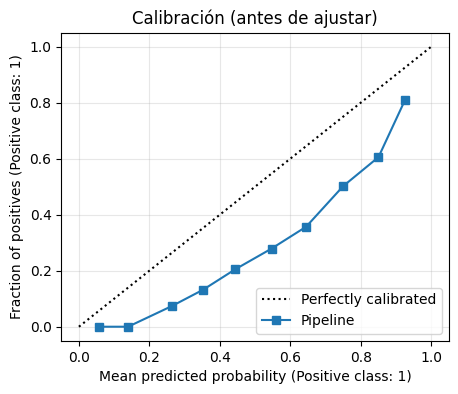

In [216]:
CalibrationDisplay.from_estimator(pipe, X_valid, y_valid, n_bins=10, strategy='uniform')
plt.title('Calibración (antes de ajustar)')
plt.grid(alpha=0.3)
plt.show()

In [217]:
cal = CalibratedClassifierCV(pipe, method='sigmoid', cv='prefit')
cal.fit(X_valid, y_valid)
y_prob_cal = cal.predict_proba(X_valid)[:,1]
print('Brier tras calibrar:', brier_score_loss(y_valid, y_prob_cal).round(3))

Brier tras calibrar: 0.148


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


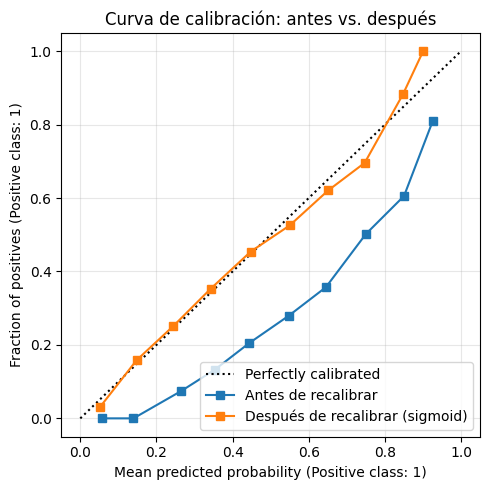

In [218]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(5, 5))

# --- Curva del modelo sin recalibrar ---
CalibrationDisplay.from_estimator(
    pipe,                # modelo base (pipeline)
    X_valid, y_valid,
    n_bins=10,
    strategy="uniform",
    name="Antes de recalibrar",
    ax=ax
)

# --- Curva del modelo recalibrado ---
CalibrationDisplay.from_estimator(
    cal,                 # modelo calibrado con Platt
    X_valid, y_valid,
    n_bins=10,
    strategy="uniform",
    name="Después de recalibrar (sigmoid)",
    ax=ax
)

ax.set_title("Curva de calibración: antes vs. después")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [219]:
from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

y_pred = cal.predict(X_valid)
y_prob = cal.predict_proba(X_valid)[:,1]
print('ROC-AUC:', roc_auc_score(y_valid,y_prob).round(3))
print('Brier :', brier_score_loss(y_valid,y_prob).round(3))
print('Confusion\n', confusion_matrix(y_valid,y_pred))
print(classification_report(y_valid,y_pred, digits=3))


prec, rec, thresholds = precision_recall_curve(y_valid, y_prob)


threshold = 0.50
y_pred = (y_prob >= threshold).astype(int)

precision = precision_score(y_valid, y_pred)  # ≈ 0.59
recall    = recall_score(y_valid, y_pred)     # ≈ 0.26

print(f'Precisión: {precision:.2%}, Recall: {recall:.2%}')


cm = confusion_matrix(y_valid, y_pred)
print(cm)

print(classification_report(y_valid, y_pred, digits=3))


ROC-AUC: 0.772
Brier : 0.148
Confusion
 [[14128   914]
 [ 3211  1607]]
              precision    recall  f1-score   support

           0      0.815     0.939     0.873     15042
           1      0.637     0.334     0.438      4818

    accuracy                          0.792     19860
   macro avg      0.726     0.636     0.655     19860
weighted avg      0.772     0.792     0.767     19860

Precisión: 63.74%, Recall: 33.35%
[[14128   914]
 [ 3211  1607]]
              precision    recall  f1-score   support

           0      0.815     0.939     0.873     15042
           1      0.637     0.334     0.438      4818

    accuracy                          0.792     19860
   macro avg      0.726     0.636     0.655     19860
weighted avg      0.772     0.792     0.767     19860



In [220]:
""""
Precisión: 62.18%, Recall: 21.72%
[[95364  1384]
 [ 8197  2275]]
              precision    recall  f1-score   support

           0      0.921     0.986     0.952     96748
           1      0.622     0.217     0.322     10472

    accuracy                          0.911    107220
   macro avg      0.771     0.601     0.637    107220
weighted avg      0.892     0.911     0.891    107220

"""

'"\nPrecisión: 62.18%, Recall: 21.72%\n[[95364  1384]\n [ 8197  2275]]\n              precision    recall  f1-score   support\n\n           0      0.921     0.986     0.952     96748\n           1      0.622     0.217     0.322     10472\n\n    accuracy                          0.911    107220\n   macro avg      0.771     0.601     0.637    107220\nweighted avg      0.892     0.911     0.891    107220\n\n'

In [221]:
y_pred_03 = (y_prob_cal >= 0.4).astype(int)
tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_03).ravel()
precision = tp / (tp+fp)
recall    = tp / (tp+fn)
print(f"Precisión {precision:.2f}, Recall {recall:.2f}")


Precisión 0.59, Recall 0.42


In [222]:
future_df = calendar[calendar['date']=='2025-04-25'].copy()
future_df['prob'] = cal.predict_proba(future_df[features])[:,1]
high = future_df[future_df['prob']>=0.50].sort_values(['date','prob'], ascending=[True,False])
high[["client", "prob"]]

,client,prob
80184,1235245925,0.880420
31098,1037669214,0.858761
307632,901666930,0.847453
304230,901569974,0.840134
270696,800180330,0.839206
...,...,...
314922,94487151,0.524548
38874,1046669122,0.519599
229872,52716745,0.515104
76782,1152696416,0.503720


## Back-Testing

In [223]:

cols = [
    'date_sale',
    'id_point_sale',
    'identification_doct',
    'product',
    'invoice_value_with_discount_and_without_iva',
    'domicilio_status',
    'amount'
    
]
ventas_back = pd.read_csv(
    "../data/raw/ventas_backtesting_new.csv",
     usecols=cols,
     dtype={'identification_doct': str,'product': str}).rename(columns={'identification_doct': 'client'})

In [224]:
ventas_back['client'] = ventas_back['client'].str.strip()
ventas_back['product'] = ventas_back['product'].str.strip()

ventas_back['date_sale'] = pd.to_datetime(
    ventas_back['date_sale'],
    errors='coerce'
)

#ventas_back = ventas_back[ventas_back["domicilio_status"]]
clients_past = calendar["client"].unique()

# Quitamos clientes nuevos
ventas_back = ventas_back[ventas_back["client"].isin(clients_past)]
ventas_back.shape

(19605, 7)

In [225]:
clientes_by_day = ventas_back[["client", "date_sale"]].drop_duplicates()


In [226]:
clientes_by_day.groupby('date_sale').size()

date_sale
2025-04-22    149
2025-04-23    233
2025-04-24    160
2025-04-25    220
2025-04-27    127
2025-04-28    151
2025-04-29    143
2025-04-30    241
2025-05-01    156
dtype: int64

In [228]:
fechas = pd.date_range('2025-04-22', '2025-04-30', freq="D")
records = []
for fecha in fechas:

    clientes_by_day_15 = clientes_by_day[clientes_by_day["date_sale"]==fecha]

    future_df = calendar[calendar['date']==fecha].copy()
    future_df['prob'] = cal.predict_proba(future_df[features])[:,1]
    high = future_df[future_df['prob']>=0.50].sort_values(['date','prob'], ascending=[True,False])

    rev_back = pd.merge(clientes_by_day_15, high, on="client", how='outer', indicator=True)


    # y_true = 1 si realmente compró (both o left_only), 0 si no compró (right_only)
    rev_back['y_true'] = rev_back['_merge'].isin(['both', 'left_only']).astype(int)

    # y_pred = 1 si el modelo predijo compra (both o right_only), 0 si predijo no compra (left_only)
    rev_back['y_pred'] = rev_back['_merge'].isin(['both', 'right_only']).astype(int)


    counts = rev_back["_merge"].value_counts()

    tp = counts.get("both", 0)
    fp = counts.get("right_only", 0)
    fn = counts.get("left_only", 0)

    # 1) Precision: TP / (TP + FP)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # 2) Recall: TP / (TP + FN)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    # 3) Fβ‑score (por ejemplo, F0.5 para dar más peso a la precisión)
    from sklearn.metrics import fbeta_score
    # O bien, calcularlo manualmente:
    beta = 0.5
    f05 = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (precision + recall) > 0 else 0

    records.append({
            'fecha_comparacion': fecha,
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'Precision': precision,
            'Recall': recall,
            'F0.5-score': f05
        })

metrics_df = pd.DataFrame(records).round(2)



In [229]:
metrics_df

,fecha_comparacion,TP,FP,FN,Precision,Recall,F0.5-score
0,2025-04-22,43,27,106,0.61,0.29,0.50
1,2025-04-23,60,15,173,0.80,0.26,0.56
2,2025-04-24,46,21,114,0.69,0.29,0.54
3,2025-04-25,57,8,163,0.88,0.26,0.59
4,2025-04-26,0,23,0,0.00,0.00,0.00
5,2025-04-27,10,2,117,0.83,0.08,0.29
6,2025-04-28,7,2,144,0.78,0.05,0.19
7,2025-04-29,7,1,136,0.88,0.05,0.20
8,2025-04-30,4,0,237,1.00,0.02,0.08


In [231]:
metrics_df["Precision"].mean(), metrics_df["Recall"].mean()

(0.7188888888888889, 0.14444444444444446)